<a href="https://colab.research.google.com/github/Trannganne/face-mask-tracking-system/blob/feature%2Fyolo_model/training_updated.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Chạy trong Google Colab:



In [ ]:
# Mount drive và giải nén
from google.colab import drive
drive.mount('/content/drive')
#!unzip -oq "/content/drive/MyDrive/KimNgan_project/Dataset_mask.zip" -d /content/dataset

Mounted at /content/drive


In [ ]:
!pip install torch torchvision opencv-python pillow matplotlib seaborn scikit-learn
!pip install deep-sort-realtime
!apt-get install -y libsndfile1
!pip install soundfile
!pip install facenet-pytorch  # Để detect face

In [ ]:
# Xử lý xung đột version
!pip install "numpy>=2.0" "torch>=2.4" "torchvision>=0.19" facenet-pytorch

In [ ]:
#Kiểm tra các phiên bản
import numpy as np
import torch
import torchvision
from facenet_pytorch import MTCNN, InceptionResnetV1
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    precision_recall_fscore_support
)

print(f"NumPy: {np.__version__}")
print(f"Torch: {torch.__version__}")
print(f"TorchVision: {torchvision.__version__}")
print(f"GPU Available: {torch.cuda.is_available()}")

# Chạy thử một lệnh của facenet-pytorch
try:
    mtcnn = MTCNN()
    print("facenet-pytorch hoạt động bình thường trên NumPy 2.x!")
except Exception as e:
    print(f"Có lỗi phát sinh: {e}")

NumPy: 2.4.6
Torch: 2.12.0+cu130
TorchVision: 0.27.0+cu130
GPU Available: True
facenet-pytorch hoạt động bình thường trên NumPy 2.x!


In [ ]:
from facenet_pytorch import InceptionResnetV1

model = InceptionResnetV1(pretrained='vggface2')
print("Load model OK")

  0%|          | 0.00/107M [00:00<?, ?B/s]

Load model OK


In [ ]:
import torch
t = torch.cuda.get_device_properties(0)
print(f"Tổng bộ nhớ GPU: {t.total_memory / 1024**2:.2f} MB")

Tổng bộ nhớ GPU: 14912.69 MB


In [ ]:
# ============================================================
# TRANSFER LEARNING - MobileNetV2 (AN TOÀN CHO ĐỒ ÁN)
# ============================================================

import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import models

class MaskDetectionTransfer(nn.Module):

    def __init__(self, num_classes=3):
        super(MaskDetectionTransfer, self).__init__()

        # Load MobileNetV2 pretrained
        self.model = models.mobilenet_v2(pretrained=True)

        # Freeze backbone
        for param in self.model.features.parameters():
            param.requires_grad = False

        # Thay classifier cuối
        in_features = self.model.classifier[1].in_features

        self.model.classifier = nn.Sequential(
            nn.Dropout(0.4),
            nn.Linear(in_features, 256),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(256, num_classes)
        )

    def forward(self, x):
        return self.model(x)

KIẾN TRÚC MODEL: Transfer Learning với MobileNetV2

INPUT:
(batch, 3, 128, 128) - Ảnh RGB kích thước 128x128

BACKBONE: MobileNetV2 Pretrained
- Sử dụng MobileNetV2 pretrained trên ImageNet
- Bao gồm các lớp:
  + Convolution layer đầu vào
  + Depthwise Separable Convolution
  + Inverted Residual Blocks
  + Batch Normalization
  + ReLU6 activation

- Feature extractor được freeze:
  for param in self.model.features.parameters():
      param.requires_grad = False

→ Chỉ huấn luyện phần classifier cuối
→ Giúp giảm thời gian train và hạn chế overfitting

FEATURE EXTRACTION:
- MobileNetV2 trích xuất đặc trưng từ ảnh đầu vào
- Output feature vector:
  (batch, 1280)

CUSTOM CLASSIFIER:

CLASSIFIER BLOCK:
- Dropout: p=0.4

- Fully Connected 1:
  Linear(1280 → 256)
  - ReLU activation

- Dropout: p=0.3

- Fully Connected 2 (Output):
  Linear(256 → 3)

OUTPUT:
(batch, 3) - Logits cho 3 classes:
  0: Đeo sai cách (incorrect_mask)
  1: Đeo đúng cách (with_mask)
  2: Không đeo (without_mask)

ĐẶC ĐIỂM MÔ HÌNH:
- Sử dụng Transfer Learning từ ImageNet
- Lightweight architecture phù hợp realtime
- Tối ưu cho deployment và DeepSORT integration
- Giảm số lượng tham số cần train
- Huấn luyện nhanh hơn Custom CNN

TỔNG SỐ THAM SỐ:
- Tổng parameters MobileNetV2: ~3.5 triệu
- Trainable parameters: chủ yếu ở classifier cuối

============= Bước 3: HÀM TỐI ƯU HÓA ====================

 HÀM TRAIN MODEL
    
    Optimizer: Adam
    - Learning rate: 0.001
    - Weight decay: 1e-4 (L2 regularization)
    
    Loss Function: CrossEntropyLoss
    
    Learning Rate Scheduler: ReduceLROnPlateau
    - Giảm LR khi val_loss không giảm sau 5 epochs
    - Factor: 0.5 (giảm 50%)
    
    Early Stopping:
    - Dừng nếu val_loss không cải thiện sau 10 epochs

In [ ]:
# ============================================================
# TRAIN MODEL - SO SÁNH ADAM VÀ SGD
# ============================================================

import torch
import torch.nn as nn
import torch.optim as optim
import time
import json

def train_model(
    model,
    train_loader,
    val_loader,
    num_epochs=10,
    optimizer_name="adam"
):

    device = torch.device(
        'cuda' if torch.cuda.is_available() else 'cpu'
    )

    model.to(device)

    # ========================================================
    # LOSS FUNCTION
    # ========================================================
    criterion = nn.CrossEntropyLoss()

    # ========================================================
    # CHỌN OPTIMIZER
    # ========================================================
    if optimizer_name.lower() == "adam":

        optimizer = optim.Adam(
            filter(lambda p: p.requires_grad, model.parameters()),
            lr=0.001,
            weight_decay=1e-4
        )

        print("\nĐang sử dụng optimizer: ADAM")

    elif optimizer_name.lower() == "sgd":

        optimizer = optim.SGD(
            filter(lambda p: p.requires_grad, model.parameters()),
            lr=0.01,
            momentum=0.9,
            weight_decay=1e-4
        )

        print("\nĐang sử dụng optimizer: SGD + Momentum")

    else:
        raise ValueError("Optimizer không hợp lệ!")

    # ========================================================
    # LEARNING RATE SCHEDULER
    # ========================================================
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(
        optimizer,
        mode='min',
        factor=0.5,
        patience=2
    )

    # ========================================================
    # EARLY STOPPING
    # ========================================================
    best_val_loss = float('inf')

    patience = 5

    patience_counter = 0

    # ========================================================
    # HISTORY
    # ========================================================
    history = {
        'train_loss': [],
        'val_loss': [],
        'train_acc': [],
        'val_acc': []
    }

    # ========================================================
    # TRAINING LOOP
    # ========================================================
    for epoch in range(num_epochs):

        start_time = time.time()

        # ====================================================
        # TRAIN
        # ====================================================
        model.train()

        running_loss = 0.0

        train_correct = 0

        train_total = 0

        for images, labels in train_loader:

            images = images.to(device)

            labels = labels.to(device)

            # Forward
            outputs = model(images)

            loss = criterion(outputs, labels)

            # Backward
            optimizer.zero_grad()

            loss.backward()

            optimizer.step()

            # Statistics
            running_loss += loss.item()

            _, predicted = torch.max(outputs, 1)

            train_total += labels.size(0)

            train_correct += (predicted == labels).sum().item()

        train_loss = running_loss / len(train_loader)

        train_acc = 100 * train_correct / train_total

        # ====================================================
        # VALIDATION
        # ====================================================
        model.eval()

        val_loss = 0.0

        val_correct = 0

        val_total = 0

        with torch.no_grad():

            for images, labels in val_loader:

                images = images.to(device)

                labels = labels.to(device)

                outputs = model(images)

                loss = criterion(outputs, labels)

                val_loss += loss.item()

                _, predicted = torch.max(outputs, 1)

                val_total += labels.size(0)

                val_correct += (predicted == labels).sum().item()

        val_loss = val_loss / len(val_loader)

        val_acc = 100 * val_correct / val_total

        # ====================================================
        # UPDATE LEARNING RATE
        # ====================================================
        scheduler.step(val_loss)

        # ====================================================
        # SAVE HISTORY
        # ====================================================
        history['train_loss'].append(train_loss)

        history['val_loss'].append(val_loss)

        history['train_acc'].append(train_acc)

        history['val_acc'].append(val_acc)

        # ====================================================
        # THỜI GIAN TRAIN
        # ====================================================
        epoch_time = time.time() - start_time

        # ====================================================
        # OUTPUT KIỂU KERAS
        # ====================================================
        print(
            f"\nEpoch {epoch+1}/{num_epochs}"
        )

        print(
            f"{len(train_loader)}/{len(train_loader)} "
            f"━━━━━━━━━━━━━━━━━━━━ "
            f"{epoch_time:.0f}s "
            f"- accuracy: {train_acc/100:.4f} "
            f"- loss: {train_loss:.4f} "
            f"- val_accuracy: {val_acc/100:.4f} "
            f"- val_loss: {val_loss:.4f}"
        )

        # ====================================================
        # EARLY STOPPING
        # ====================================================
        if val_loss < best_val_loss:

            best_val_loss = val_loss

            patience_counter = 0

            torch.save(
                model.state_dict(),
                f'/content/drive/MyDrive/best_model_{optimizer_name}.pth'
            )

            print("Đã lưu model tốt nhất!")

        else:

            patience_counter += 1

            print(f"Không cải thiện ({patience_counter}/{patience})")

            if patience_counter >= patience:

                print(f"\nDừng sớm tại epoch {epoch+1}")

                break

    save_path = f"/content/drive/MyDrive/history_{optimizer_name}.json"

    with open(save_path, "w") as f:
        json.dump(history, f)

    return model, history

BƯỚC 4: HÀM ĐÁNH GIÁ

 Metrics:
    
    - Precision: TP / (TP + FP)
    
    - Recall: TP / (TP + FN)
    
    - F1-Score: 2 * (Precision * Recall) / (Precision + Recall)
    
    - Confusion Matrix


In [ ]:
from sklearn.metrics import confusion_matrix, classification_report, precision_recall_fscore_support

def evaluate_model(model, test_loader, class_names=['Đeo sai', 'Đeo đúng', 'Không đeo']):
  device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
  model.to(device)
  model.eval()

  all_preds = []
  all_labels = []

  with torch.no_grad():
      for images, labels in test_loader:
          images = images.to(device)
          outputs = model(images)
          _, predicted = torch.max(outputs.data, 1)

          all_preds.extend(predicted.cpu().numpy())
          all_labels.extend(labels.numpy())

  # Calculate metrics
  precision, recall, f1, support = precision_recall_fscore_support(
      all_labels, all_preds, average=None
    )

  # IN metrics
  print("\n"+"="*60)
  print("Đánh giá model")
  print("="*60)

  for i, class_name in enumerate(class_names):
    print(f"{class_name}:")
    print(f"Precision: {precision[i]:.4f}")
    print(f"Recall: {recall[i]:.4f}")
    print(f"F1-Score: {f1[i]:.4f}")
    print(f"Support: {support[i]}")

  # Metrics tổng quan
  overall_precision = np.mean(precision)
  overall_recall = np.mean(recall)
  overall_f1 = np.mean(f1)

  print("\n"+"="*60)
  print(f"Precision: {overall_precision:.4f}")
  print(f"Recall: {overall_recall:.4f}")
  print(f"F1-Score: {overall_f1:.4f}")
  print("="*60)

  # Confusion matrix
  cm = confusion_matrix(all_labels, all_preds)
  print("Confusion Matrix:")
  print(cm)

  # Báo cáo phân loại
  print("\n Báo cáo")
  print(classification_report(all_labels, all_preds, target_names=class_names))

  # Ma trận nhầm lẫn
  cm=confusion_matrix(all_labels, all_preds)

  plt.figure(figsize=(10,8))
  sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
  plt.title('Confusion Matrix', fontsize=16, fontweight='bold')
  plt.xlabel('Predicted Label', fontsize=12)
  plt.ylabel('True Label', fontsize=12)
  plt.tight_layout()
  plt.savefig('confusion_matrix.png',dpi=300, bbox_inches='tight')
  plt.show()

  return precision, recall, f1

BƯỚC 5: DEEPSORT TRACKING + CẢNH BÁO
Chức năng:
    - Track từng người bằng DeepSORT
    - Đếm thời gian không đeo khẩu trang
    - Phát cảnh báo nếu > 20s

---
## Cập nhật: PersonTrackerV2 (Logic đúng + 10s)


In [ ]:
# ============================================================
# ⏱️ TRACKER CẬP NHẬT: đếm thời gian ĐEO KHẨU TRANG
#    - Đeo vào (with_mask)  → bắt đầu đếm
#    - Tháo ra / đeo sai    → reset về 0
#    - Vượt 10 giây         → CẢnh BÁO ĐỎ
# ============================================================
from collections import defaultdict
import time

class PersonTrackerV2:
    """
    DeepSORT tracker kết hợp đếm thời gian đeo khẩu trang.

    CLASS IDs (theo ImageFolder thứ tự alphabet):
        0 = mask_weared_incorrect  (đeo sai)
        1 = with_mask              (đeo đúng)
        2 = without_mask           (không đeo)

    Logic cảnh báo:
        - Nếu class == 1 (đeo đúng): bắt đầu / tiếp tục đếm
        - Nếu class != 1            : reset về 0
        - Nếu thời gian đeo > ALERT_SECONDS: hiện CẢNH BÁO
    """
    ALERT_SECONDS = 10          # ← Ngưỡng cảnh báo (giây)

    def __init__(self):
        from deep_sort_realtime.deepsort_tracker import DeepSort
        self.tracker = DeepSort(
            max_age=30,
            n_init=3,
            nn_budget=100,
            max_iou_distance=0.7
        )
        # Trạng thái mỗi track_id
        self.states = defaultdict(lambda: {
            "mask_start": None,      # thời điểm bắt đầu đeo
            "mask_duration": 0.0,    # tổng thời gian đang đeo
            "last_class": None,
            "alerted": False,
        })

    # ── Cập nhật mỗi frame ──────────────────────────────────
    def update(self, detections, frame_rgb, current_time):
        """
        detections: list of (bbox_xyxy, confidence, class_id)
        frame_rgb:  numpy array (H,W,3) — cần cho DeepSORT appearance
        current_time: float (giây từ đầu video)
        Returns: list of result dicts
        """
        ds_input = []
        for (x1, y1, x2, y2), conf, cls in detections:
            ds_input.append(([x1, y1, x2 - x1, y2 - y1], conf, cls))

        tracks = self.tracker.update_tracks(ds_input, frame=frame_rgb)
        results = []

        for track in tracks:
            if not track.is_confirmed():
                continue

            tid    = track.track_id
            bbox   = track.to_ltrb()          # (x1,y1,x2,y2)
            cls_id = track.get_det_class()
            st     = self.states[tid]

            # ── Logic đếm thời gian ──────────────────────
            if cls_id == 1:                    # đang đeo đúng
                if st["mask_start"] is None:
                    st["mask_start"] = current_time   # bắt đầu đếm
                st["mask_duration"] = current_time - st["mask_start"]
            else:                              # tháo ra / đeo sai
                st["mask_start"]    = None
                st["mask_duration"] = 0.0
                st["alerted"]       = False   # reset cảnh báo

            # ── Kiểm tra ngưỡng ──────────────────────────
            alert = (cls_id == 1 and st["mask_duration"] > self.ALERT_SECONDS)
            if alert and not st["alerted"]:
                print(f"CẢNH BÁO! ID {tid} đeo khẩu trang "
                      f"{st['mask_duration']:.1f}s > {self.ALERT_SECONDS}s")
                st["alerted"] = True

            st["last_class"] = cls_id
            results.append({
                "track_id":      tid,
                "bbox":          bbox,
                "class_id":      cls_id,
                "mask_duration": st["mask_duration"],
                "alert":         alert,
            })

        return results

    # ── Vẽ kết quả lên frame ────────────────────────────────
    @staticmethod
    def draw(frame, results, class_names):
        COLOR_MAP = {
            0: (0, 165, 255),   # đeo sai  → cam
            1: (0, 255, 0),     # đeo đúng → xanh lá
            2: (0, 0, 255),     # không đeo → đỏ
        }
        for r in results:
            x1, y1, x2, y2 = map(int, r["bbox"])
            cls   = r["class_id"]
            dur   = r["mask_duration"]
            alert = r["alert"]
            color = COLOR_MAP.get(cls, (200, 200, 200))

            # Bounding box (đậm hơn khi cảnh báo)
            thickness = 4 if alert else 2
            cv2.rectangle(frame, (x1, y1), (x2, y2), color, thickness)

            # Nhãn + ID
            label = f"ID:{r['track_id']} {class_names[cls]}"
            cv2.putText(frame, label, (x1, y1 - 10),
                        cv2.FONT_HERSHEY_SIMPLEX, 0.6, color, 2)

            # Thời gian đeo (chỉ hiện khi đang đeo)
            if cls == 1:
                time_txt = f"Thoi gian deo: {dur:.1f}s"
                cv2.putText(frame, time_txt, (x1, y2 + 20),
                            cv2.FONT_HERSHEY_SIMPLEX, 0.55, (0, 255, 0), 2)

            # Banner cảnh báo đỏ
            if alert:
                overlay = frame.copy()
                cv2.rectangle(overlay, (x1, y1 - 55), (x2, y1 - 12),
                              (0, 0, 220), -1)
                cv2.addWeighted(overlay, 0.6, frame, 0.4, 0, frame)
                cv2.putText(frame,
                            f"!! CANH BAO: {dur:.0f}s !!",
                            (x1 + 4, y1 - 22),
                            cv2.FONT_HERSHEY_SIMPLEX, 0.65, (255, 255, 255), 2)
        return frame

print(f"PersonTrackerV2 sẵn sàng — ngưỡng cảnh báo: {PersonTrackerV2.ALERT_SECONDS}s")


PersonTrackerV2 sẵn sàng — ngưỡng cảnh báo: 10s


BƯỚC 6: INFERENCE VIDEO

---
## Cập nhật: process_video_v2


In [ ]:
# ============================================================
#  PROCESS VIDEO — SỬ DỤNG PersonTrackerV2 ĐÃ CẬP NHẬT
# ============================================================
from facenet_pytorch import MTCNN
import cv2, torch, time
from PIL import Image
from torchvision import transforms

def process_video_v2(model, video_path, output_path="output_video.mp4",
                     alert_seconds=10):
    """
    Xử lý video với tracking + đếm thời gian đeo khẩu trang.
    Cảnh báo khi đeo > alert_seconds giây.
    """
    PersonTrackerV2.ALERT_SECONDS = alert_seconds

    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model  = model.to(device).eval()

    mtcnn   = MTCNN(keep_all=True, device=device)
    tracker = PersonTrackerV2()

    cap    = cv2.VideoCapture(video_path)
    fourcc = cv2.VideoWriter_fourcc(*"mp4v")
    fps    = int(cap.get(cv2.CAP_PROP_FPS)) or 25
    W      = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
    H      = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
    out    = cv2.VideoWriter(output_path, fourcc, fps, (W, H))

    transform = transforms.Compose([
        transforms.Resize((128, 128)),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ])
    class_names = ["mask_weared_incorrect", "with_mask", "without_mask"]

    t0, frame_no = time.time(), 0

    while cap.isOpened():
        ret, frame = cap.read()
        if not ret:
            break
        frame_no   += 1
        now         = time.time() - t0
        img_rgb     = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
        boxes, probs = mtcnn.detect(img_rgb)

        detections = []
        if boxes is not None:
            for box, prob in zip(boxes, probs):
                if prob is None or prob < 0.9:
                    continue
                x1, y1, x2, y2 = map(int, box)
                face = img_rgb[max(0,y1):y2, max(0,x1):x2]
                if face.size == 0:
                    continue
                face_t = transform(Image.fromarray(face)).unsqueeze(0).to(device)
                with torch.no_grad():
                    out_t  = model(face_t)
                    cls_id = out_t.argmax(dim=1).item()
                    conf   = out_t.softmax(dim=1)[0][cls_id].item()
                detections.append(([x1, y1, x2, y2], conf, cls_id))

        results = tracker.update(detections, img_rgb, now)
        frame   = PersonTrackerV2.draw(frame, results, class_names)

        # Overlay FPS & thời gian
        cv2.putText(frame, f"Frame {frame_no} | {now:.1f}s",
                    (10, 25), cv2.FONT_HERSHEY_SIMPLEX, 0.65, (200, 200, 200), 1)
        out.write(frame)

        if frame_no % 60 == 0:
            print(f"  ✔ {frame_no} frames — {now:.1f}s elapsed")

    cap.release(); out.release()
    print(f"\n✅ Video đã lưu: {output_path}")

# Sử dụng:
# model.load_state_dict(torch.load("/content/drive/MyDrive/best_mask_model.pth"))
# process_video_v2(model, "input.mp4", "output.mp4", alert_seconds=10)
print("✅ process_video_v2() sẵn sàng sử dụng")


✅ process_video_v2() sẵn sàng sử dụng


In [ ]:
# CHuẩn bị và cân bằng dữ liệu
import os
import random
from collections import defaultdict, Counter
from torchvision.datasets import ImageFolder
from torch.utils.data import DataLoader, Subset
from torchvision import transforms

# ===== Hàm giới hạn số lượng mỗi class =====
def limit_dataset_per_class(dataset, max_per_class=1750):
    class_indices = defaultdict(list)

    # Gom index theo class
    for idx, label in enumerate(dataset.targets):
        class_indices[label].append(idx)

    selected_indices = []

    for label, indices in class_indices.items():
        if len(indices) > max_per_class:
            indices = random.sample(indices, max_per_class)
        selected_indices.extend(indices)

    random.shuffle(selected_indices)

    return Subset(dataset, selected_indices)

# ===== Hàm chuẩn bị dữ liệu =====
def prepare_data(data_dir='/content/dataset/Dataset_mask', batch_size=32, balance_train=True):

    # ============================================================
# TRAIN TRANSFORM
# ============================================================
    train_transform = transforms.Compose([

    transforms.Resize((128, 128)),

    transforms.RandomHorizontalFlip(p=0.5),

    transforms.RandomRotation(10),

    transforms.ColorJitter(
        brightness=0.15,
        contrast=0.15
    ),

    transforms.ToTensor(),

    transforms.Normalize(
        [0.485, 0.456, 0.406],
        [0.229, 0.224, 0.225]
    )
])

# ============================================================
# VAL / TEST TRANSFORM
# ============================================================
    test_transform = transforms.Compose([

    transforms.Resize((128, 128)),

    transforms.ToTensor(),

    transforms.Normalize(
        [0.485, 0.456, 0.406],
        [0.229, 0.224, 0.225]
    )
])

    # Load dataset
    train_set = ImageFolder(
    os.path.join(data_dir, 'train'),
    transform=train_transform
)

    val_set = ImageFolder(
    os.path.join(data_dir, 'val'),
    transform=test_transform
)

    test_set = ImageFolder(
    os.path.join(data_dir, 'test'),
    transform=test_transform
)

    print(" Trước khi cân bằng:")
    print("Train:", Counter(train_set.targets))
    print("Val:", Counter(val_set.targets))
    print("Test:", Counter(test_set.targets))

    #  Cân bằng train
    if balance_train:
        train_set = limit_dataset_per_class(train_set, max_per_class=1750)

        # Lấy lại labels sau khi subset
        subset_labels = [train_set.dataset.targets[i] for i in train_set.indices]
        print("\n Sau khi cân bằng Train:")
        print("Train:", Counter(subset_labels))

    # DataLoader
    train_loader = DataLoader(train_set, batch_size=batch_size, shuffle=True)
    val_loader = DataLoader(val_set, batch_size=batch_size, shuffle=False)
    test_loader = DataLoader(test_set, batch_size=batch_size, shuffle=False)

    return train_loader, val_loader, test_loader

In [ ]:
from collections import Counter
import torch

def get_labels(dataset):
    if isinstance(dataset, torch.utils.data.Subset):
        return [dataset.dataset.targets[i] for i in dataset.indices]
    return dataset.targets

train_loader, val_loader, test_loader = prepare_data()

# lấy dataset từ loader
train_set = train_loader.dataset
val_set = val_loader.dataset
test_set = test_loader.dataset

print("Train:", Counter(get_labels(train_set)))
print("Val:", Counter(get_labels(val_set)))
print("Test:", Counter(get_labels(test_set)))

FileNotFoundError: [Errno 2] No such file or directory: '/content/dataset/Dataset_mask/train'

BƯỚC 7: MAIN - CHẠY TRÊN COLAB

In [ ]:
def main():

    print("="*60)
    print("MASK DETECTION - OPTIMIZER COMPARISON")
    print("="*60)

    # =========================
    # DATA
    # =========================
    train_loader, val_loader, test_loader = prepare_data()

    # ========================================================
    # TRAIN ADAM
    # ========================================================
    print("\nTRAINING WITH ADAM\n")

    model_adam = MaskDetectionTransfer(num_classes=3)

    model_adam, history_adam = train_model(
        model_adam,
        train_loader,
        val_loader,
        num_epochs=10,
        optimizer_name="adam"
    )

    # ========================================================
    # TRAIN SGD
    # ========================================================
    print("\nTRAINING WITH SGD\n")

    model_sgd = MaskDetectionTransfer(num_classes=3)

    model_sgd, history_sgd = train_model(
        model_sgd,
        train_loader,
        val_loader,
        num_epochs=10,
        optimizer_name="sgd"
    )

    # ========================================================
    # LOAD BEST MODEL (optional nhưng nên có)
    # ========================================================
    model_adam.load_state_dict(
        torch.load("/content/drive/MyDrive/best_model_adam.pth")
    )

    model_sgd.load_state_dict(
        torch.load("/content/drive/MyDrive/best_model_sgd.pth")
    )

    # ========================================================
    # EVALUATE
    # ========================================================
    print("\nEVALUATE ADAM")
    evaluate_model(model_adam, test_loader)

    print("\nEVALUATE SGD")
    evaluate_model(model_sgd, test_loader)

    # ========================================================
    # PLOT COMPARISON LOSS / ACC
    # ========================================================
    plot_comparison(history_adam, history_sgd)


    print("\nHOÀN THÀNH SO SÁNH OPTIMIZER!")

if __name__ == "__main__":
      main()


EVALUATE ADAM

Đánh giá model
Đeo sai:
Precision: 0.9633
Recall: 0.8400
F1-Score: 0.8974
Support: 375
Đeo đúng:
Precision: 0.6673
Recall: 0.9413
F1-Score: 0.7810
Support: 375
Không đeo:
Precision: 0.8810
Recall: 0.6320
F1-Score: 0.7360
Support: 375

Precision: 0.8372
Recall: 0.8044
F1-Score: 0.8048
Confusion Matrix:
[[315  49  11]
 [  1 353  21]
 [ 11 127 237]]

 Báo cáo
              precision    recall  f1-score   support

     Đeo sai       0.96      0.84      0.90       375
    Đeo đúng       0.67      0.94      0.78       375
   Không đeo       0.88      0.63      0.74       375

    accuracy                           0.80      1125
   macro avg       0.84      0.80      0.80      1125
weighted avg       0.84      0.80      0.80      1125



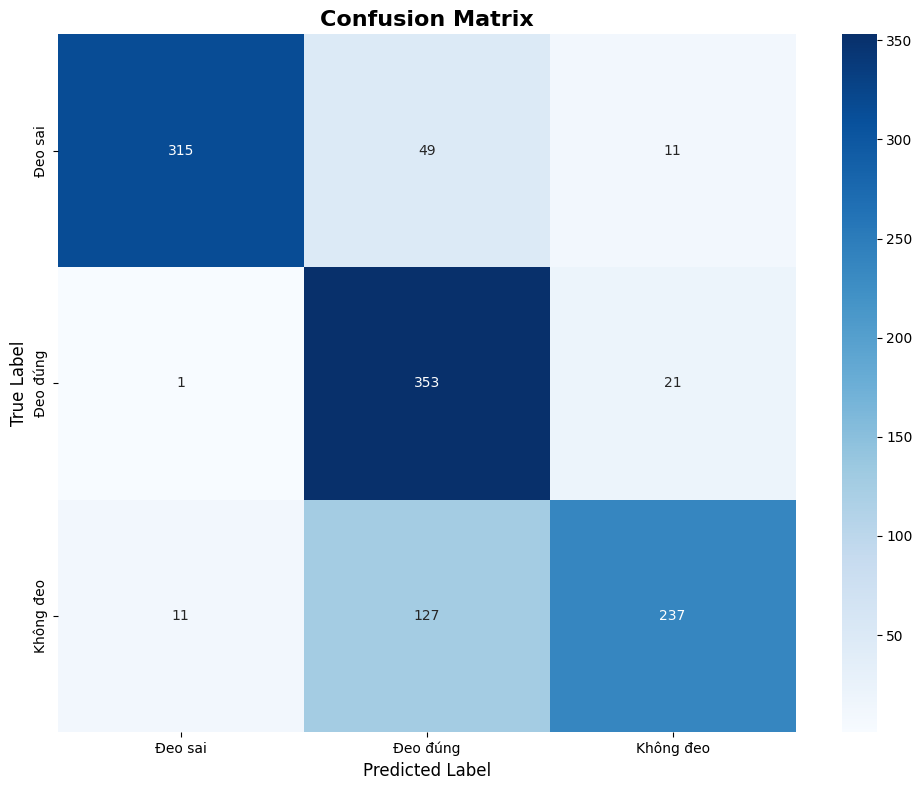

(array([0.96330275, 0.66729679, 0.88104089]),
 array([0.84      , 0.94133333, 0.632     ]),
 array([0.8974359 , 0.78097345, 0.73602484]))

In [ ]:
model_adam = MaskDetectionTransfer(num_classes=3)
model_adam.load_state_dict(
        torch.load("/content/drive/MyDrive/best_model_adam.pth")
    )
print("\nEVALUATE ADAM")
evaluate_model(model_adam, test_loader)

In [ ]:
import matplotlib.pyplot as plt

def plot_comparison(history_adam, history_sgd):

    # Epoch riêng cho từng optimizer
    epochs_adam = range(1, len(history_adam["train_loss"]) + 1)

    epochs_sgd = range(1, len(history_sgd["train_loss"]) + 1)

    plt.figure(figsize=(12, 5))

    # ====================================================
    # LOSS
    # ====================================================
    plt.subplot(1, 2, 1)

    plt.plot(
        epochs_adam,
        history_adam["val_loss"],
        label="Adam",
        linewidth=2
    )

    plt.plot(
        epochs_sgd,
        history_sgd["val_loss"],
        label="SGD",
        linewidth=2
    )

    plt.title("Validation Loss Comparison")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.legend()
    plt.grid(alpha=0.3)

    # ====================================================
    # ACCURACY
    # ====================================================
    plt.subplot(1, 2, 2)

    plt.plot(
        epochs_adam,
        history_adam["val_acc"],
        label="Adam",
        linewidth=2
    )

    plt.plot(
        epochs_sgd,
        history_sgd["val_acc"],
        label="SGD",
        linewidth=2
    )

    plt.title("Validation Accuracy Comparison")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy (%)")
    plt.legend()
    plt.grid(alpha=0.3)

    plt.tight_layout()

    plt.savefig(
        "/content/drive/MyDrive/optimizer_comparison.png",
        dpi=120
    )

    plt.show()

    print("Đã lưu optimizer_comparison.png")

---
## Sơ đồ Loss & Accuracy


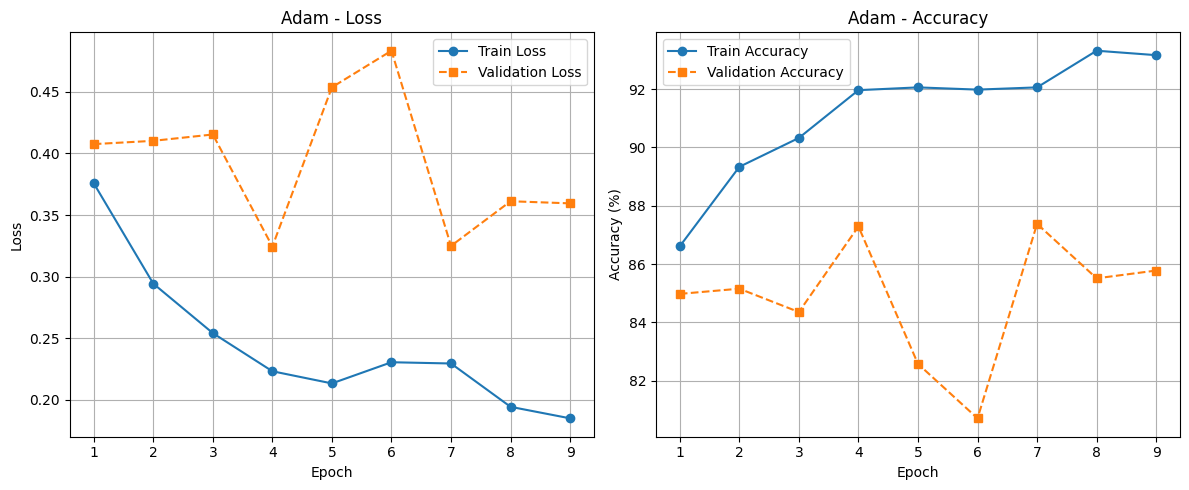

Đã lưu biểu đồ Adam


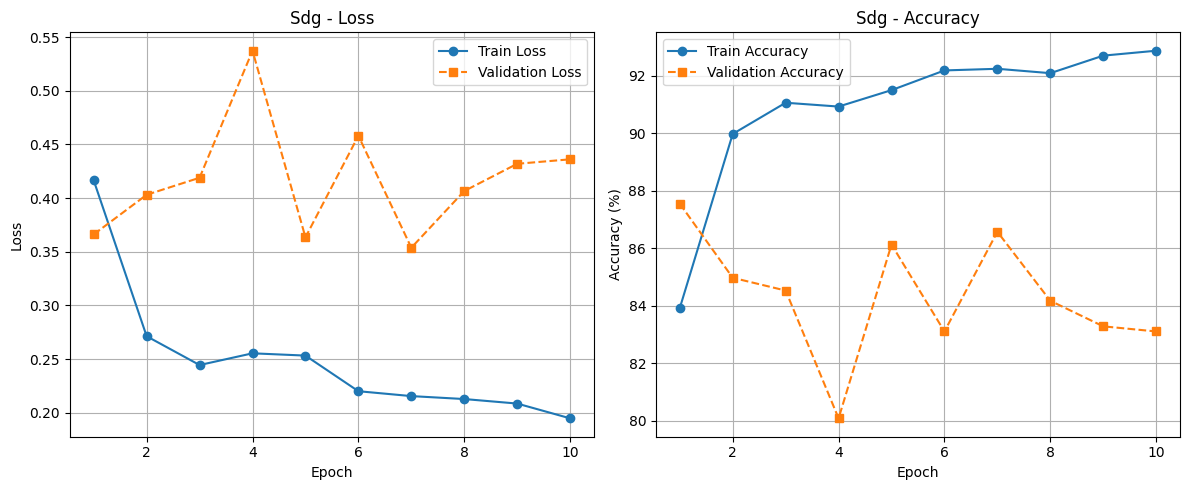

Đã lưu biểu đồ Sdg


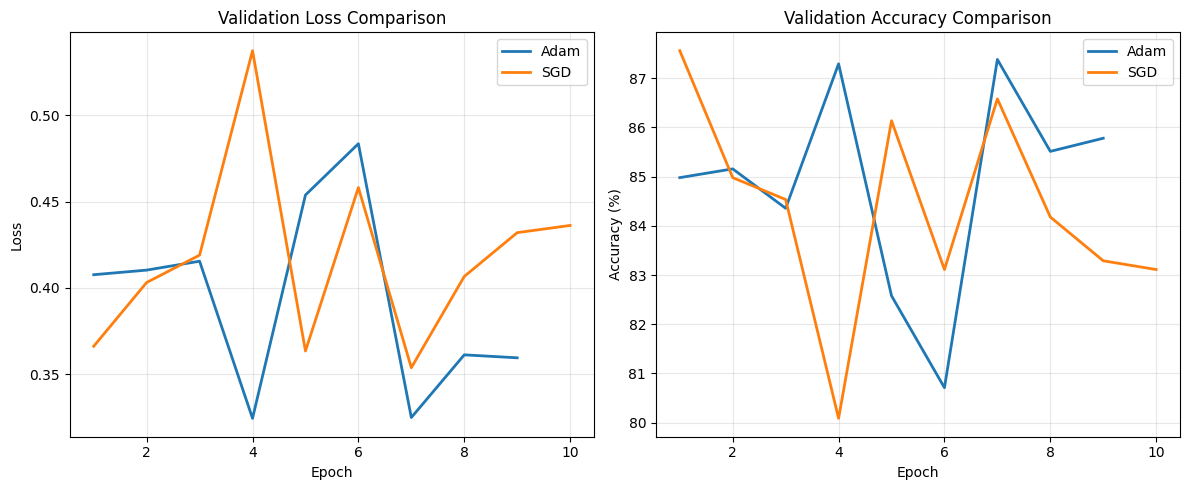

Đã lưu optimizer_comparison.png


In [ ]:
# ============================================================
#  VẼ SƠ ĐỒ LOSS & ACCURACY (STYLE BASIC)
# ============================================================
import matplotlib.pyplot as plt
import json

def plot_training_history(history, optimizer_name="Model"):

    epochs = range(1, len(history["train_loss"]) + 1)

    plt.figure(figsize=(12, 5))

    # ==========================================
    # LOSS
    # ==========================================
    plt.subplot(1, 2, 1)

    plt.plot(
        epochs,
        history["train_loss"],
        label="Train Loss",
        marker="o"
    )

    plt.plot(
        epochs,
        history["val_loss"],
        label="Validation Loss",
        marker="s",
        linestyle="--"
    )

    plt.title(f"{optimizer_name} - Loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.legend()
    plt.grid(True)

    # ==========================================
    # ACCURACY
    # ==========================================
    plt.subplot(1, 2, 2)

    plt.plot(
        epochs,
        history["train_acc"],
        label="Train Accuracy",
        marker="o"
    )

    plt.plot(
        epochs,
        history["val_acc"],
        label="Validation Accuracy",
        marker="s",
        linestyle="--"
    )

    plt.title(f"{optimizer_name} - Accuracy")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy (%)")
    plt.legend()
    plt.grid(True)

    plt.tight_layout()

    plt.savefig(
        f"/content/drive/MyDrive/{optimizer_name}_training_history.png",
        dpi=120
    )

    plt.show()

    print(f"Đã lưu biểu đồ {optimizer_name}")

# ==================================================================
# VẼ LOSS/ ACCURACY SAU KHI TRAIN

with open("/content/drive/MyDrive/history_adam.json", "r") as f:
    history_adam = json.load(f)

with open("/content/drive/MyDrive/history_sgd.json", "r") as f:
    history_sgd = json.load(f)

plot_training_history(history_adam,"Adam")
plot_training_history(history_sgd, "Sdg")

plot_comparison(history_adam, history_sgd)
# ============================================================
# DEMO TEST
# ============================================================
# demo_history = {
#     "train_loss": [1.1, 0.85, 0.65, 0.50, 0.40, 0.33, 0.27, 0.23, 0.20, 0.18],
#     "val_loss":   [1.0, 0.80, 0.62, 0.52, 0.45, 0.42, 0.40, 0.39, 0.38, 0.37],

#     "train_acc":  [45, 62, 74, 82, 87, 90, 92, 94, 95, 96],
#     "val_acc":    [48, 60, 72, 79, 83, 84, 85, 86, 86.5, 87],
# }

# plot_training_history(demo_history)

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=MobileNet_V2_Weights.IMAGENET1K_V1`. You can also use `weights=MobileNet_V2_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


=== Feature Map -- All Classes ===
Loaded 3 sample(s)

Class: Deo sai


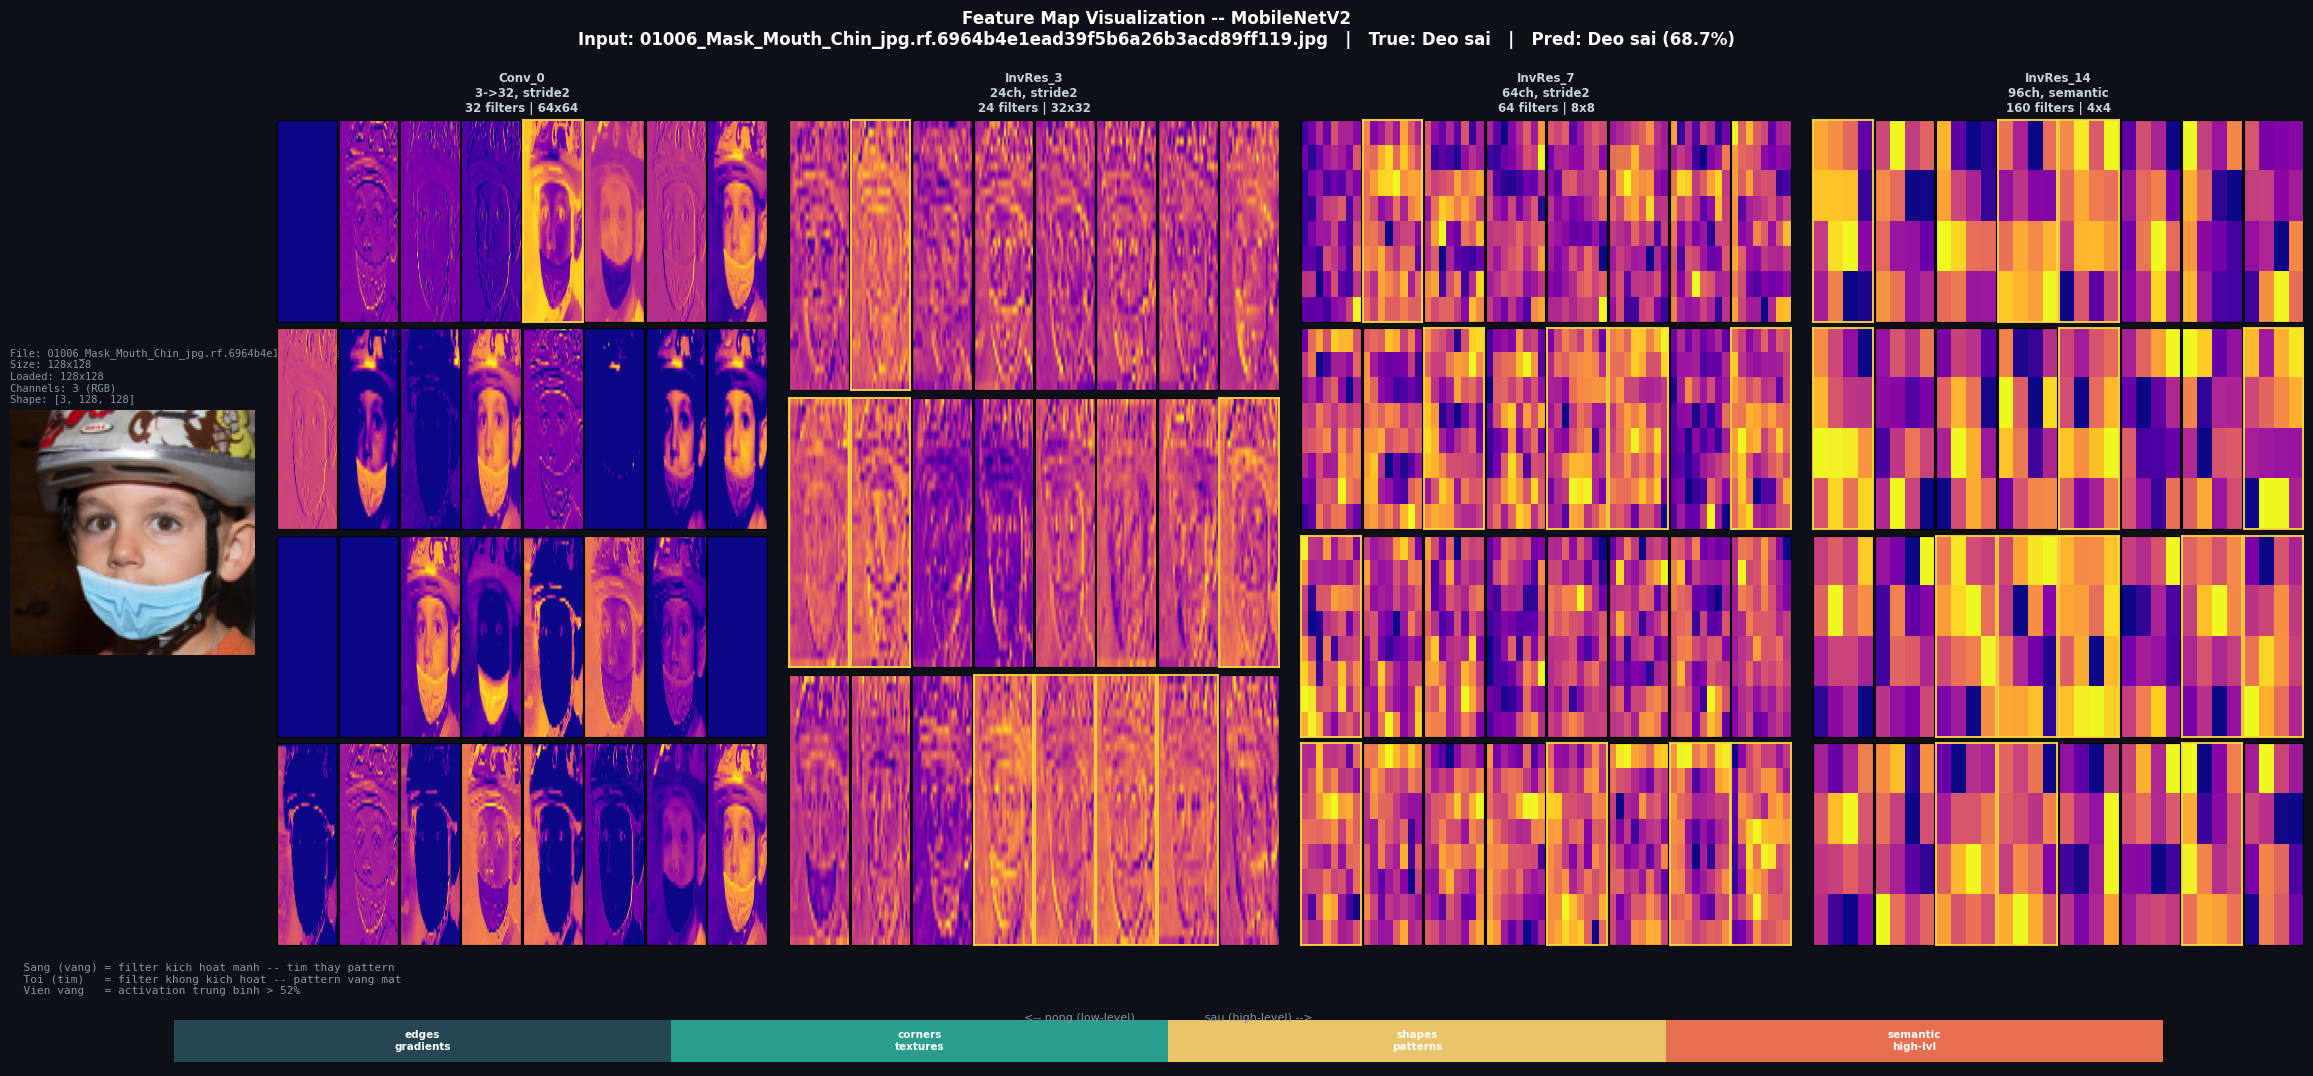

  Da luu: /content/drive/MyDrive/KimNgan_project/featuremap_0.png

Class: Deo dung


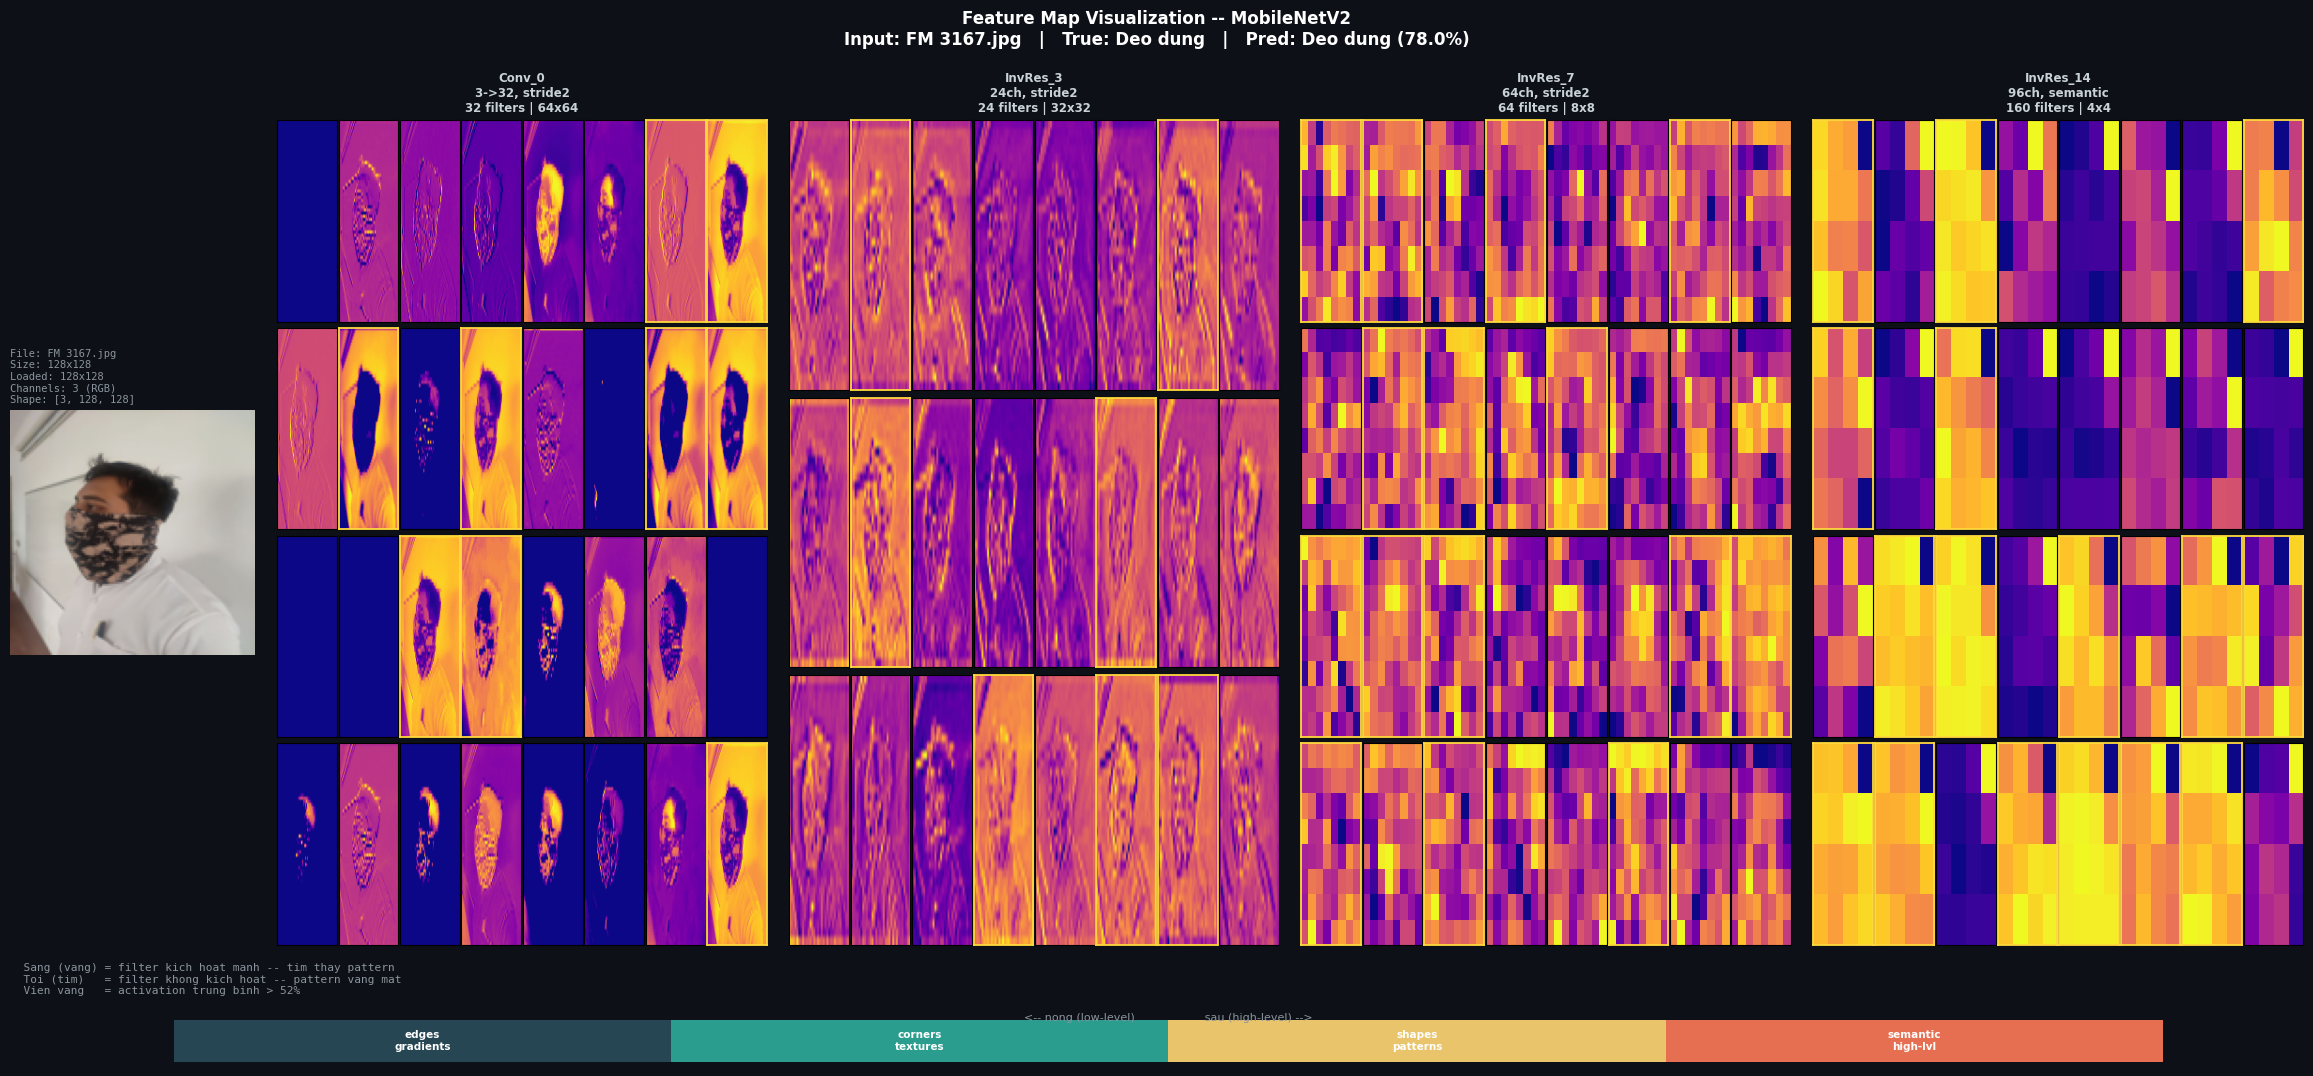

  Da luu: /content/drive/MyDrive/KimNgan_project/featuremap_1.png

Class: Khong deo


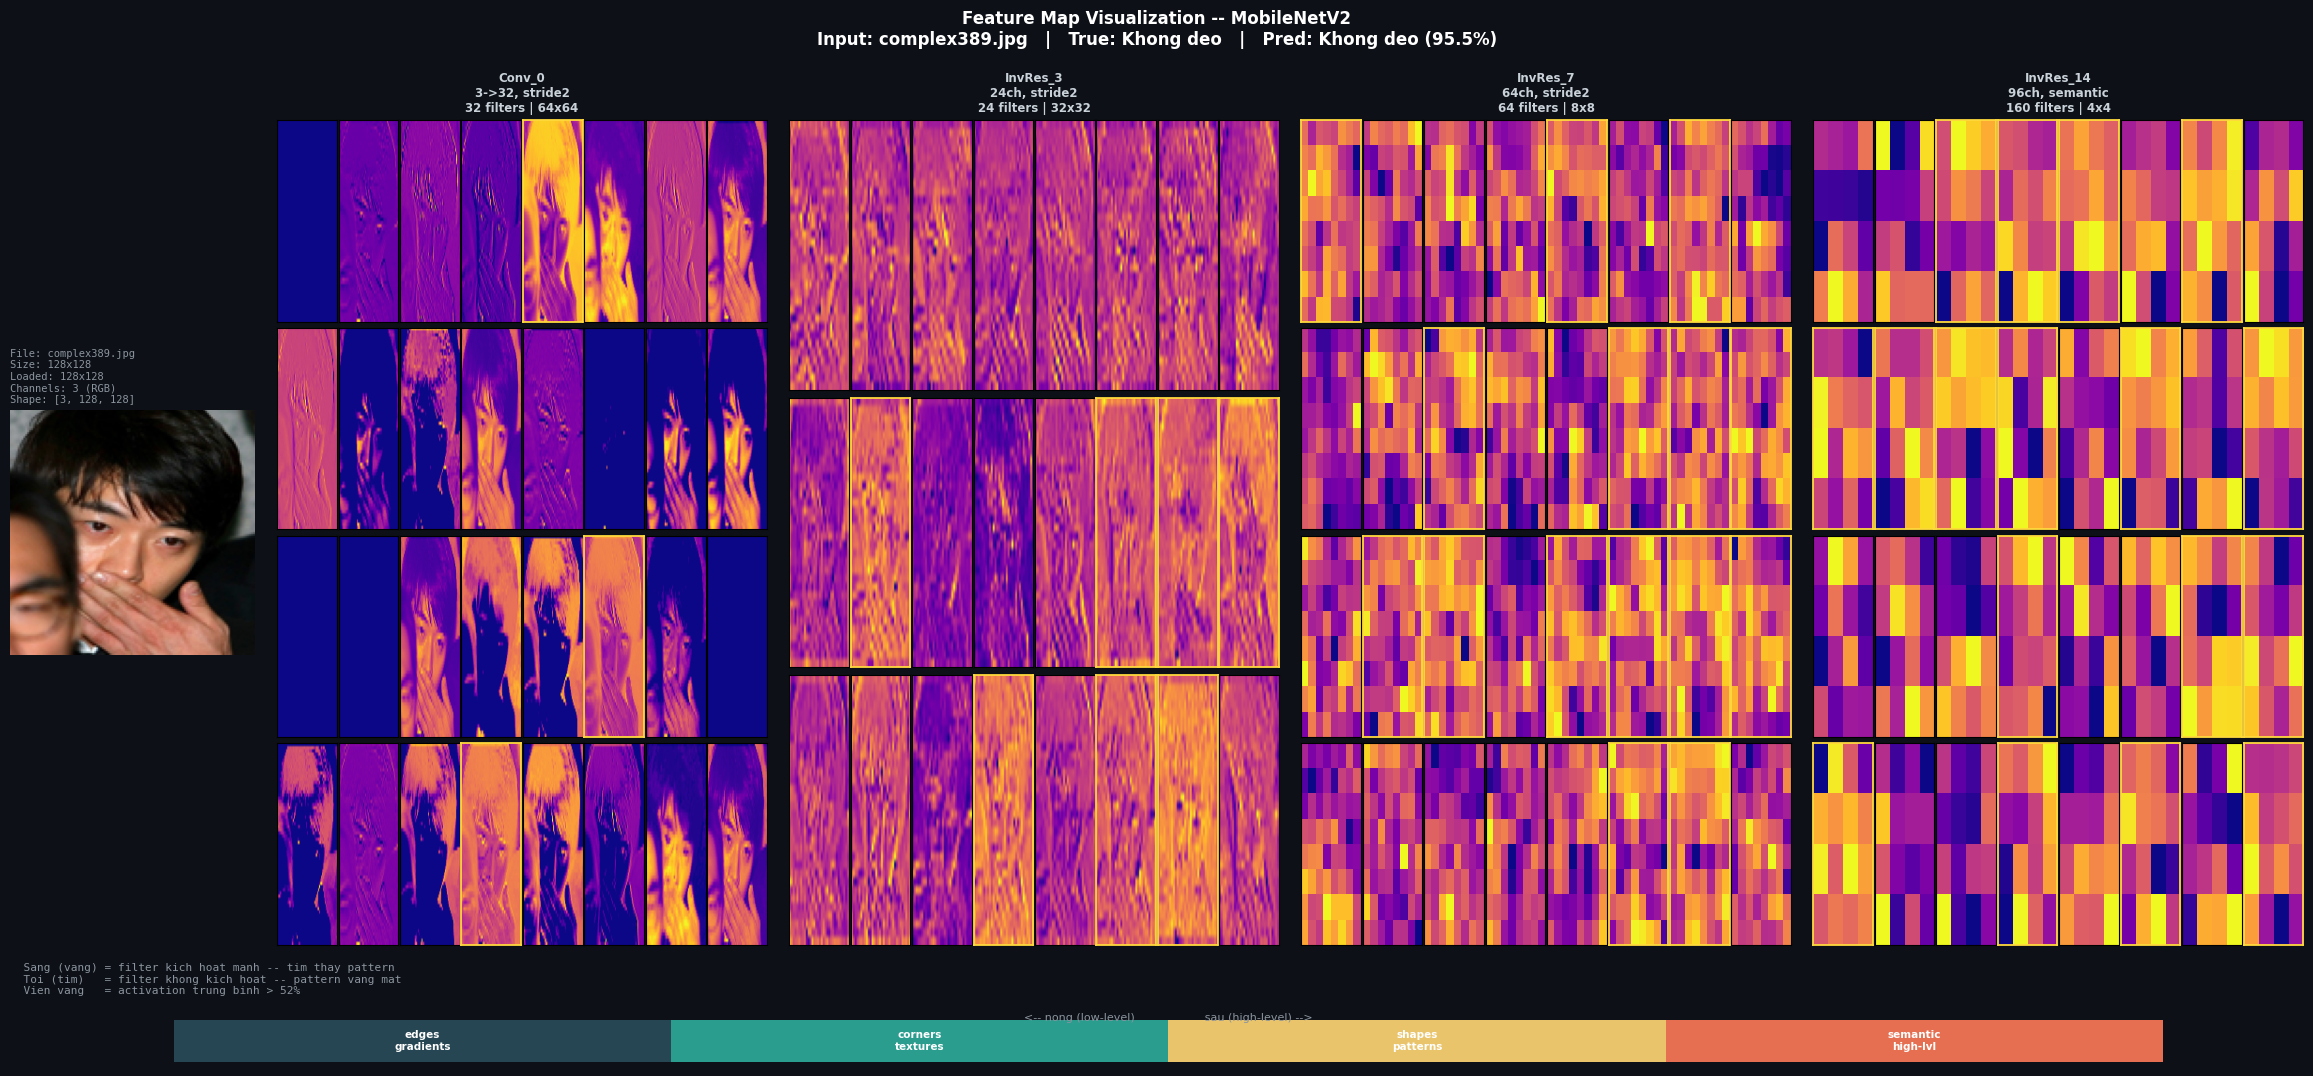

  Da luu: /content/drive/MyDrive/KimNgan_project/featuremap_2.png

Hoan thanh Feature Map Visualization!
Loaded 3 sample(s)


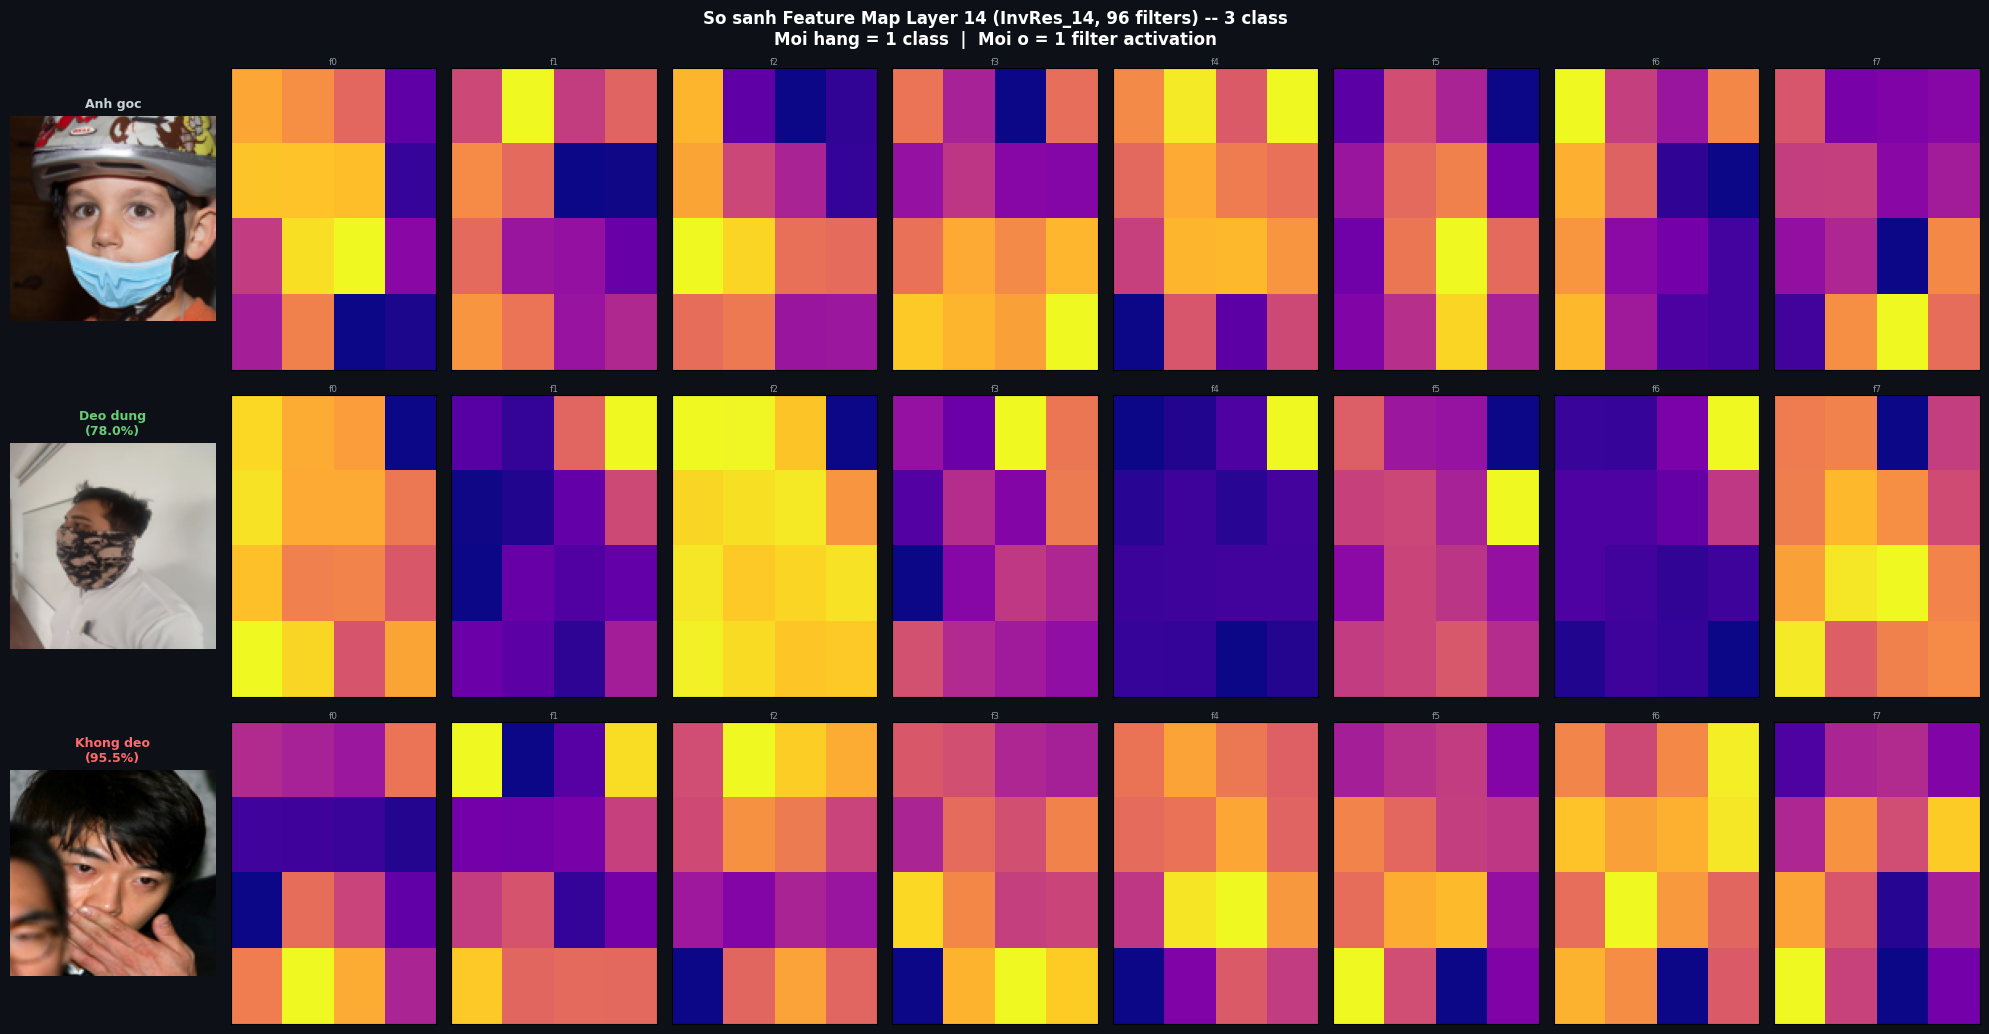

Da luu so sanh: /content/drive/MyDrive/KimNgan_project/featuremap_compare.png
Loaded 3 sample(s)


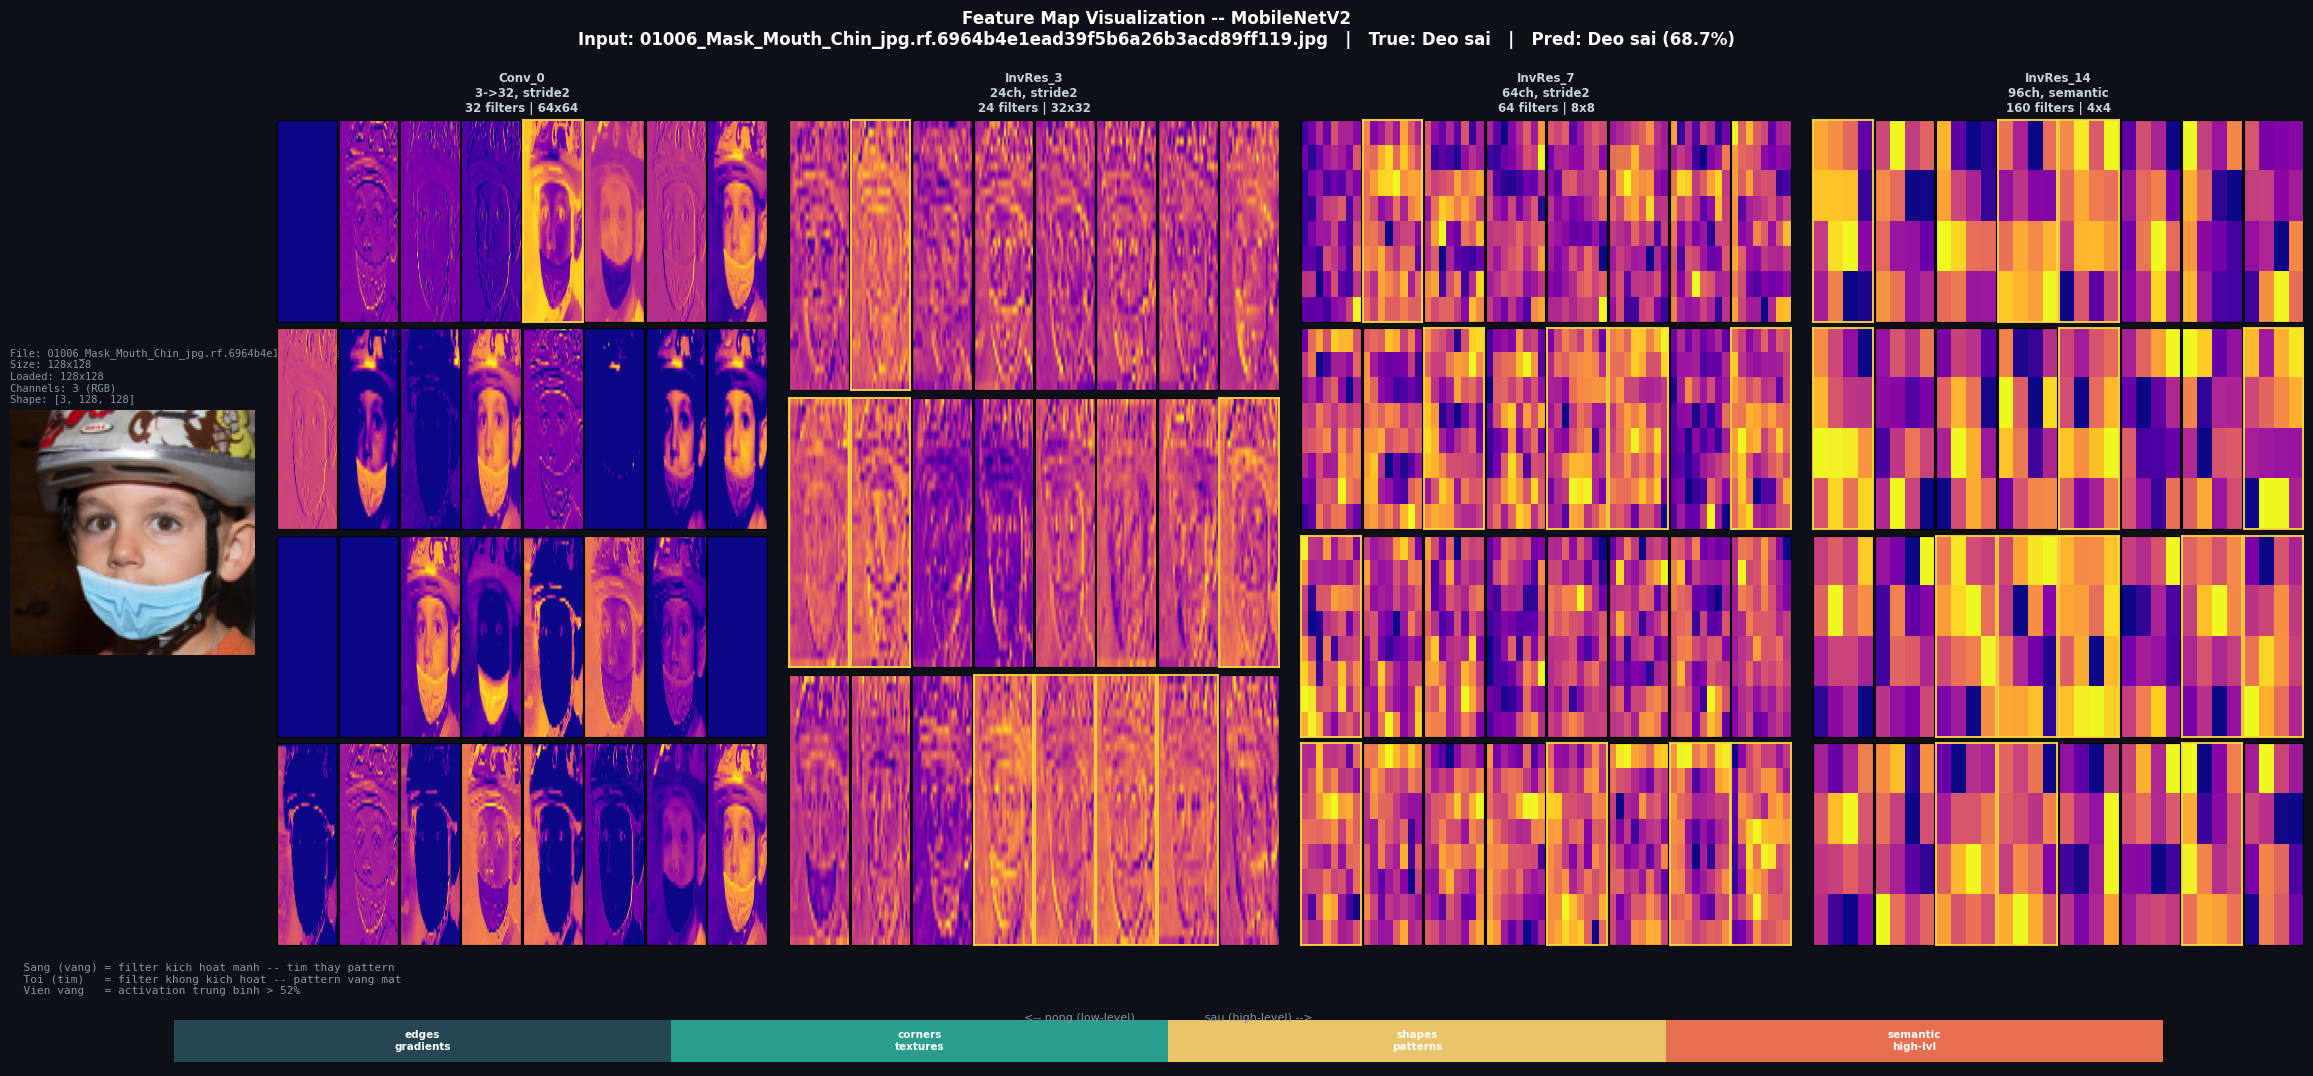

  Da luu: /content/drive/MyDrive/KimNgan_project/featuremap_0.png
Feature Map Visualization san sang!
  Goi: visualize_all_classes(best_model)
  Goi: compare_feature_maps(best_model)


In [ ]:
# ============================================================
# FEATURE MAP VISUALIZATION -- MobileNetV2
# ============================================================
# Cach dung sau khi train:
#   visualize_all_classes(best_model)      -- 3 anh, 3 class
#   compare_feature_maps(best_model)       -- so sanh layer cuoi
#   plot_feature_maps(best_model, sample)  -- 1 anh bat ky
# ============================================================

import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from torchvision import transforms
from PIL import Image
import os

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# ------------------------------------------------------------------
# CONFIG
# ------------------------------------------------------------------
CLASS_NAMES  = ['0', '1', '2']
CLASS_VI     = {'0': 'Deo sai', '1': 'Deo dung', '2': 'Khong deo'}
CLASS_COLORS = {'0': '#ffd93d',  '1': '#6bcb77',  '2': '#ff6b6b'}

MEAN = np.array([0.485, 0.456, 0.406])
STD  = np.array([0.229, 0.224, 0.225])

# 4 layers dai dien: nong -> sau
LAYER_CONFIGS = [
    {'index':  0, 'label': 'Conv_0\n3->32, stride2',       'max_f': 32},
    {'index':  3, 'label': 'InvRes_3\n24ch, stride2',       'max_f': 24},
    {'index':  7, 'label': 'InvRes_7\n64ch, stride2',       'max_f': 32},
    {'index': 14, 'label': 'InvRes_14\n96ch, semantic',     'max_f': 48},
]

TRANSFORM = transforms.Compose([
    transforms.Resize((128, 128)),
    transforms.ToTensor(),
    transforms.Normalize(MEAN, STD)
])

# ------------------------------------------------------------------
# STEP 1: LOAD ANH MAU
# ------------------------------------------------------------------
def load_sample_images(data_dir='/content/dataset/Dataset_mask/test', n_per_class=1):
    samples = []
    for cls_id, cls_name in enumerate(CLASS_NAMES):
        cls_dir = os.path.join(data_dir, cls_name)
        if not os.path.isdir(cls_dir):
            print(f'  Khong tim thay: {cls_dir}')
            continue
        files = sorted([
            f for f in os.listdir(cls_dir)
            if f.lower().endswith(('.jpg', '.jpeg', '.png'))
        ])[:n_per_class]
        for fname in files:
            fpath  = os.path.join(cls_dir, fname)
            img    = Image.open(fpath).convert('RGB').resize((128, 128))
            img_np = np.array(img)
            tensor = TRANSFORM(img).unsqueeze(0).to(device)
            samples.append((tensor, img_np, cls_id, cls_name, fpath))
    print(f'Loaded {len(samples)} sample(s)')
    return samples

# ------------------------------------------------------------------
# STEP 2: HOOK FEATURE MAPS
# ------------------------------------------------------------------
def get_feature_maps(model, img_tensor, layer_indices):
    model.eval()
    activations = {}
    handles = []

    def make_hook(idx):
        def hook(module, inp, out):
            activations[idx] = out.detach().cpu()
        return hook

    for idx in layer_indices:
        h = model.model.features[idx].register_forward_hook(make_hook(idx))
        handles.append(h)

    with torch.no_grad():
        out   = model(img_tensor)
        probs = torch.softmax(out, dim=1)[0].cpu().numpy()
        pred  = int(probs.argmax())

    for h in handles:
        h.remove()

    return activations, probs, pred

# ------------------------------------------------------------------
# STEP 3: PLOT GRID -- GIONG ANH THAM KHAO
# ------------------------------------------------------------------
def plot_feature_maps(model, sample,
                      save_path=None,
                      grid_cols=8, grid_rows=4):
    img_tensor, img_np, true_cls, true_name, fpath = sample
    layer_indices = [c['index'] for c in LAYER_CONFIGS]
    activations, probs, pred = get_feature_maps(model, img_tensor, layer_indices)

    pred_name  = CLASS_NAMES[pred]
    pred_color = CLASS_COLORS[pred_name]

    n_layers = len(LAYER_CONFIGS)

    # Figure: 1 cot anh goc + n_layers cot grid
    fig = plt.figure(figsize=(4.2 + n_layers * 4.8, 11))
    fig.patch.set_facecolor('#0d1117')

    outer = gridspec.GridSpec(
        1, 1 + n_layers,
        figure=fig,
        width_ratios=[1] + [2] * n_layers,
        wspace=0.05,
        left=0.01, right=0.99, top=0.87, bottom=0.12
    )

    # ---- Col 0: anh goc + info ----
    ax0 = fig.add_subplot(outer[0, 0])
    ax0.imshow(img_np)
    ax0.axis('off')
    ax0.set_facecolor('#161b22')

    fname = os.path.basename(fpath)
    info  = (f'File: {fname}\n'
             f'Size: {img_np.shape[1]}x{img_np.shape[0]}\n'
             f'Loaded: 128x128\n'
             f'Channels: {img_np.shape[2]} (RGB)\n'
             f'Shape: [{img_tensor.shape[1]}, 128, 128]')
    ax0.set_title(info, fontsize=7.5, color='#8b949e',
                  loc='left', pad=5, fontfamily='monospace')
    ax0.set_xlabel(
        f'True:  {CLASS_VI[true_name]}\n'
        f'Pred:  {CLASS_VI[pred_name]}  ({probs[pred]:.1%})',
        fontsize=9, color=pred_color, labelpad=6
    )

    # ---- Col 1..N: filter grids ----
    for col, cfg in enumerate(LAYER_CONFIGS):
        lidx   = cfg['index']
        label  = cfg['label']
        max_f  = cfg['max_f']

        fmap = activations.get(lidx)
        if fmap is None:
            continue
        fmap = fmap[0]              # (C, H, W)
        C    = min(fmap.shape[0], max_f)
        n_r  = min(grid_rows, (C + grid_cols - 1) // grid_cols)
        n_c  = min(grid_cols, C)

        inner = gridspec.GridSpecFromSubplotSpec(
            n_r, n_c,
            subplot_spec=outer[0, col + 1],
            hspace=0.03, wspace=0.03
        )

        for r in range(n_r):
            for c in range(n_c):
                fi = r * n_c + c
                ax = fig.add_subplot(inner[r, c])
                ax.set_facecolor('#0d1117')
                ax.set_xticks([]); ax.set_yticks([])

                if fi < C:
                    fm     = fmap[fi].numpy()
                    fm_min = fm.min(); fm_max = fm.max()
                    fm_n   = (fm - fm_min) / (fm_max - fm_min + 1e-8)
                    ax.imshow(fm_n, cmap='plasma', aspect='auto')
                    # vien vang khi kich hoat manh
                    if fm_n.mean() > 0.52:
                        for sp in ax.spines.values():
                            sp.set_edgecolor('#ffd93d')
                            sp.set_linewidth(1.3)
                            sp.set_visible(True)
                else:
                    ax.set_facecolor('#161b22')

        # header cot
        C_total = fmap.shape[0]
        sp_str  = f'{fmap.shape[1]}x{fmap.shape[2]}'
        header  = f'{label}\n{C_total} filters | {sp_str}'
        # dung axes am muu de dat title ben tren inner grid
        ghost = fig.add_subplot(outer[0, col + 1])
        ghost.set_title(header, fontsize=8.5,
                        color='#c9d1d9', fontweight='bold', pad=6)
        ghost.axis('off')

    # ---- Legend mau sac ----
    fig.text(0.01, 0.075,
             ('  Sang (vang) = filter kich hoat manh -- tim thay pattern\n'
              '  Toi (tim)   = filter khong kich hoat -- pattern vang mat\n'
              '  Vien vang   = activation trung binh > 52%'),
             fontsize=8, color='#8b949e', fontfamily='monospace')

    # ---- Thanh progression ----
    bar_data = [
        ('edges\ngradients', '#264653'),
        ('corners\ntextures', '#2a9d8f'),
        ('shapes\npatterns',  '#e9c46a'),
        ('semantic\nhigh-lvl','#e76f51'),
    ]
    bax = fig.add_axes([0.08, 0.01, 0.85, 0.045])
    bax.set_facecolor('#0d1117'); bax.axis('off')
    bax.set_xlim(0, n_layers); bax.set_ylim(0, 1)
    for i, (lbl, clr) in enumerate(bar_data):
        bax.barh(0.5, 1, left=i, height=0.85, color=clr)
        bax.text(i + 0.5, 0.5, lbl,
                 ha='center', va='center', color='white',
                 fontsize=7.5, fontweight='bold')
    aax = fig.add_axes([0.08, 0.048, 0.85, 0.012])
    aax.axis('off')
    aax.text(0.5, 0.5,
             '<-- nong (low-level)                    sau (high-level) -->',
             ha='center', va='center', color='#8b949e', fontsize=8,
             transform=aax.transAxes)

    # ---- Tieu de chinh ----
    fig.suptitle(
        'Feature Map Visualization -- MobileNetV2\n'
        f'Input: {os.path.basename(fpath)}   |   '
        f'True: {CLASS_VI[true_name]}   |   '
        f'Pred: {CLASS_VI[pred_name]} ({probs[pred]:.1%})',
        fontsize=12, color='white', fontweight='bold', y=0.97
    )

    sp = save_path or f'/content/drive/MyDrive/KimNgan_project/featuremap_{true_name}.png'
    plt.savefig(sp, dpi=150, bbox_inches='tight', facecolor='#0d1117')
    plt.show()
    print(f'  Da luu: {sp}')


# ------------------------------------------------------------------
# STEP 4: VISUALIZE TAT CA CLASS
# ------------------------------------------------------------------
def visualize_all_classes(
        model,
        data_dir='/content/dataset/Dataset_mask/test',
        save_dir='/content/drive/MyDrive/KimNgan_project'):
    os.makedirs(save_dir, exist_ok=True)
    print('=== Feature Map -- All Classes ===')
    samples = load_sample_images(data_dir, n_per_class=1)
    for s in samples:
        cls_name = s[3]
        print(f'\nClass: {CLASS_VI[cls_name]}')
        sp = os.path.join(save_dir, f'featuremap_{cls_name}.png')
        plot_feature_maps(model, s, save_path=sp)
    print('\nHoan thanh Feature Map Visualization!')


# ------------------------------------------------------------------
# STEP 5: SO SANH LAYER CUOI 3 CLASS
# ------------------------------------------------------------------
def compare_feature_maps(
        model,
        data_dir='/content/dataset/Dataset_mask/test',
        save_path='/content/drive/MyDrive/KimNgan_project/featuremap_compare.png'):
    """
    1 hinh: moi hang = 1 class, cot = 8 filter dau cua layer 14.
    Ro rang su khac biet khi model nhin 3 loai.
    """
    samples     = load_sample_images(data_dir, n_per_class=1)
    COMP_LAYER  = 14
    SHOW_F      = 8
    n           = len(samples)

    fig, axes = plt.subplots(n, SHOW_F + 1, figsize=(20, n * 3.5))
    fig.patch.set_facecolor('#0d1117')
    fig.suptitle(
        f'So sanh Feature Map Layer {COMP_LAYER} (InvRes_14, 96 filters) -- 3 class\n'
        'Moi hang = 1 class  |  Moi o = 1 filter activation',
        fontsize=12, color='white', fontweight='bold'
    )

    for row, (img_tensor, img_np, true_cls, true_name, fpath) in enumerate(samples):
        acts, probs, pred = get_feature_maps(model, img_tensor, [COMP_LAYER])
        fmap = acts[COMP_LAYER][0]
        C    = min(fmap.shape[0], SHOW_F)

        # col 0: anh goc
        ax = axes[row, 0] if n > 1 else axes[0]
        ax.imshow(img_np)
        ax.axis('off')
        ax.set_facecolor('#0d1117')
        clr = CLASS_COLORS[true_name]
        ax.set_title(f'{CLASS_VI[true_name]}\n({probs[true_cls]:.1%})',
                     color=clr, fontsize=9, fontweight='bold')

        # col 1..: filters
        for fi in range(SHOW_F):
            axf = axes[row, fi + 1] if n > 1 else axes[fi + 1]
            axf.set_facecolor('#0d1117')
            axf.set_xticks([]); axf.set_yticks([])
            if fi < C:
                fm = fmap[fi].numpy()
                fm_n = (fm - fm.min()) / (fm.max() - fm.min() + 1e-8)
                axf.imshow(fm_n, cmap='plasma', aspect='auto')
                axf.set_title(f'f{fi}', fontsize=6.5, color='#8b949e', pad=2)
            else:
                axf.set_facecolor('#161b22')

        # Hang header label (chi hang dau)
        if row == 0:
            axes[0, 0].set_title('Anh goc', color='#c9d1d9',
                                 fontsize=9, fontweight='bold') if n > 1 \
                else axes[0].set_title('Anh goc', color='#c9d1d9', fontsize=9)

    plt.tight_layout()
    plt.savefig(save_path, dpi=150, bbox_inches='tight', facecolor='#0d1117')
    plt.show()
    print(f'Da luu so sanh: {save_path}')


# ================================================================
# CACH SU DUNG -- sau khi train xong
# Dùng ADAM vì kết quả tốt hơn
# ================================================================
best_model = MaskDetectionTransfer(num_classes=3)

best_model.load_state_dict(
    torch.load("/content/drive/MyDrive/best_model_adam.pth")
)
best_model=best_model.to(device)
best_model.eval()

# 1. Xem tung layer cho ca 3 class
visualize_all_classes(best_model)
#
# 2. So sanh layer cuoi giua 3 class
compare_feature_maps(best_model)
#
# 3. Mot anh bat ky
samples = load_sample_images(n_per_class=1)
plot_feature_maps(best_model, samples[0])
# ================================================================
print('Feature Map Visualization san sang!')
print('  Goi: visualize_all_classes(best_model)')
print('  Goi: compare_feature_maps(best_model)')


## GIAO DIỆN

In [ ]:
# ============================================================
# FULL GRADIO APP - LOAD MODEL + IMAGE + VIDEO (FIXED)
# ============================================================

import gradio as gr
import os
import numpy as np
import cv2
import torch
from PIL import Image
from facenet_pytorch import MTCNN
from torchvision import transforms

# ============================================================
# DEVICE
# ============================================================

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# ============================================================
# LOAD MODEL
# ============================================================

model = MaskDetectionTransfer(num_classes=3)

model.load_state_dict(
    torch.load(
        "/content/drive/MyDrive/Face_Mask_Project/best_model_adam.pth",
        map_location=device
    )
)

model = model.to(device)
model.eval()

print("✅ Model loaded")

# ============================================================
# MTCNN
# ============================================================

mtcnn = MTCNN(keep_all=True, device=device)

# ============================================================
# TRANSFORM
# ============================================================

transform = transforms.Compose([
    transforms.Resize((128, 128)),
    transforms.ToTensor(),
    transforms.Normalize(
        [0.485, 0.456, 0.406],
        [0.229, 0.224, 0.225]
    )
])

# ============================================================
# CLASS LABELS + COLORS
# ============================================================

class_names = ["Mask Incorrect", "With Mask", "Without Mask"]

colors = {
    0: (0, 165, 255),  # orange
    1: (0, 255, 0),    # green
    2: (0, 0, 255)     # red
}

# ============================================================
# IMAGE PREDICTION
# ============================================================

def predict_image(image, threshold):

    image = np.array(image)
    rgb = image.copy()

    boxes, probs = mtcnn.detect(rgb)

    result_text = ""
    count = 0

    if boxes is not None:

        for box, prob in zip(boxes, probs):

            if prob is None or prob < threshold:
                continue

            x1, y1, x2, y2 = map(int, box)

            face = rgb[max(0,y1):y2, max(0,x1):x2]

            if face.size == 0:
                continue

            face = Image.fromarray(face)
            face_tensor = transform(face).unsqueeze(0).to(device)

            with torch.no_grad():
                output = model(face_tensor)
                pred = output.argmax(dim=1).item()
                conf = torch.softmax(output, dim=1)[0][pred].item()

            count += 1
            result_text += f"{count}. {class_names[pred]} ({conf:.2f})\n"

            color = colors[pred]

            cv2.rectangle(image, (x1, y1), (x2, y2), color, 2)

            cv2.putText(
                image,
                f"{class_names[pred]} {conf:.2f}",
                (x1, y1 - 10),
                cv2.FONT_HERSHEY_SIMPLEX,
                0.7,
                color,
                2
            )

    return image, result_text

# ============================================================
# VIDEO PREDICTION
# ============================================================

def predict_video(video):

    video_path = video
    output_path = "/content/output_video.mp4"

    process_video_v2(
        model=model,
        video_path=video_path,
        output_path=output_path,
        alert_seconds=10
    )

    return output_path

# ============================================================
# GRADIO IMAGE UI
# ============================================================

image_interface = gr.Interface(
    fn=predict_image,
    inputs=[
        gr.Image(type="pil"),
        gr.Slider(0.1, 1.0, value=0.9, step=0.05)
    ],
    outputs=[
        gr.Image(type="numpy"),
        gr.Textbox()
    ],
    title="Mask Detection - Image"
)

# ============================================================
# GRADIO VIDEO UI
# ============================================================

video_interface = gr.Interface(
    fn=predict_video,
    inputs=gr.Video(label="Upload Video"),
    outputs=gr.Video(label="Output Video"),
    title="Mask Detection - Video"
)

# ============================================================
# COMBINE UI
# ============================================================

demo = gr.TabbedInterface(
    [image_interface, video_interface],
    ["Image", "Video"]
)

demo.queue()
demo.launch(debug=True)

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=MobileNet_V2_Weights.IMAGENET1K_V1`. You can also use `weights=MobileNet_V2_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/mobilenet_v2-b0353104.pth" to /root/.cache/torch/hub/checkpoints/mobilenet_v2-b0353104.pth


100%|██████████| 13.6M/13.6M [00:00<00:00, 126MB/s]


✅ Model loaded
It looks like you are running Gradio on a hosted Jupyter notebook, which requires `share=True`. Automatically setting `share=True` (you can turn this off by setting `share=False` in `launch()` explicitly).

Colab notebook detected. This cell will run indefinitely so that you can see errors and logs. To turn off, set debug=False in launch().
* Running on public URL: https://2a4f896d0118e7d138.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/gradio/queueing.py", line 759, in process_events
    response = await route_utils.call_process_api(
               ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/gradio/route_utils.py", line 354, in call_process_api
    output = await app.get_blocks().process_api(
             ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/gradio/blocks.py", line 2191, in process_api
    result = await self.call_function(
             ^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/gradio/blocks.py", line 1698, in call_function
    prediction = await anyio.to_thread.run_sync(  # type: ignore
                 ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/anyio/to_thread.py", line 63, in run_sync
    return await get_async_backend().run_sync_in_worker_thread(
           ^^^^^

In [ ]:
# ============================================================
# CELL 2 - VIDEO PROCESSING (FIXED + GUARANTEED BBOX)
# ============================================================

from google.colab import files
import os
import cv2
import torch
import time
from PIL import Image
from torchvision import transforms
from facenet_pytorch import MTCNN

# ============================================================
# UPLOAD VIDEO
# ============================================================

uploaded = files.upload()
video_path = list(uploaded.keys())[0]

output_path = "/content/output_video.mp4"

# ============================================================
# DEVICE + MODEL
# ============================================================

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = model.to(device)
model.eval()

# ============================================================
# MTCNN
# ============================================================

mtcnn = MTCNN(keep_all=True, device=device)

# ============================================================
# TRANSFORM
# ============================================================

transform = transforms.Compose([
    transforms.Resize((128, 128)),
    transforms.ToTensor(),
    transforms.Normalize(
        [0.485, 0.456, 0.406],
        [0.229, 0.224, 0.225]
    )
])

# ============================================================
# CLASS LABELS + COLORS
# ============================================================

class_names = ["Mask Incorrect", "With Mask", "Without Mask"]

colors = {
    0: (0, 165, 255),   # orange
    1: (0, 255, 0),     # green
    2: (0, 0, 255)      # red
}

# ============================================================
# VIDEO READ/WRITE
# ============================================================

cap = cv2.VideoCapture(video_path)

fps = int(cap.get(cv2.CAP_PROP_FPS)) or 25
W = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
H = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))

fourcc = cv2.VideoWriter_fourcc(*"mp4v")
out = cv2.VideoWriter(output_path, fourcc, fps, (W, H))

frame_no = 0
t0 = time.time()

# ============================================================
# MAIN LOOP
# ============================================================

while cap.isOpened():

    ret, frame = cap.read()
    if not ret:
        break

    frame_no += 1

    rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)

    boxes, probs = mtcnn.detect(rgb)

    detections = []

    # ========================================================
    # DETECTION + CLASSIFICATION
    # ========================================================

    if boxes is not None:

        for box, prob in zip(boxes, probs):

            if prob is None or prob < 0.7:
                continue

            x1, y1, x2, y2 = map(int, box)

            face = rgb[max(0,y1):y2, max(0,x1):x2]

            if face.size == 0:
                continue

            face = Image.fromarray(face)
            face_tensor = transform(face).unsqueeze(0).to(device)

            with torch.no_grad():
                output = model(face_tensor)
                pred = output.argmax(dim=1).item()
                conf = torch.softmax(output, dim=1)[0][pred].item()

            detections.append((x1, y1, x2, y2, pred, conf))

    # ========================================================
    # DRAW BOUNDING BOX (IMPORTANT FIX)
    # ========================================================

    for x1, y1, x2, y2, cls_id, conf in detections:

        color = colors[cls_id]
        label = f"{class_names[cls_id]} {conf:.2f}"

        cv2.rectangle(frame, (x1, y1), (x2, y2), color, 2)

        cv2.putText(
            frame,
            label,
            (x1, y1 - 10),
            cv2.FONT_HERSHEY_SIMPLEX,
            0.7,
            color,
            2
        )

    # ========================================================
    # INFO OVERLAY
    # ========================================================

    now = time.time() - t0

    cv2.putText(
        frame,
        f"Frame {frame_no} | {now:.1f}s",
        (10, 30),
        cv2.FONT_HERSHEY_SIMPLEX,
        0.8,
        (255, 255, 255),
        2
    )

    # ========================================================
    # WRITE FRAME
    # ========================================================

    out.write(frame)

    if frame_no % 50 == 0:
        print(f"✔ {frame_no} frames processed")

# ============================================================
# CLEANUP
# ============================================================

cap.release()
out.release()

print("\n✅ DONE:", output_path)

# ============================================================
# DISPLAY RESULT
# ============================================================

from IPython.display import Video
Video(output_path)

KeyboardInterrupt: 